[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digdgeo/Ndvi2Gif/blob/master/workshops/ecoinformatica/notebooks/01_rois_y_estadisticos.ipynb)

# ROIs y estadísticos: Doñana en media hora

**Taller Ndvi2Gif — Jornadas de Ecoinformática, Sevilla, 2 de octubre de 2026**

Dos cosas hay que aprender para usar la librería, y las dos caben en este notebook:

1. **cómo le dices dónde mirar** — cinco maneras de dar un ROI, ninguna de ellas obliga a
   tener un shapefile a mano;
2. **qué estadístico le pides** — porque el mapa cambia más con el estadístico que con el
   índice, y eso casi nunca se cuenta.

Y al final, la gracia: cuatro décadas de inundación de la marisma de Doñana con MNDWI y
Landsat, una década al lado de la otra.

## 0. Preparar el entorno

En **Google Colab**, descomenta la primera línea y ejecuta. En tu propio entorno
(conda/pip) ya tendrás la librería instalada y puedes saltarte la celda.

La primera vez en una máquina nueva hay que autenticarse en Earth Engine
(`ee.Authenticate()`), y siempre hay que inicializar con **tu** proyecto de Google Cloud:
el `PROJECT` de abajo es el único sitio donde tienes que escribir algo tuyo.

In [1]:
# !pip install -q ndvi2gif

import json
import time

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from IPython.display import Image as Animacion

from ndvi2gif import NdviSeasonality

# ee.Authenticate()        # solo la primera vez
PROJECT = 'tu-proyecto-de-earth-engine'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine listo')

/home/diego/miniconda3/envs/ndvi2gif_clean/lib/python3.9/site-packages/geemap/conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✓ Earth Engine listo


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [2]:
# un mismo aspecto para todas las figuras del notebook
VERDE = ['f7f4e9', 'd9e8a8', '94c164', '3f8f4f', '184b2e']      # NDVI: seco -> verde
AGUA = ['f2efe6', 'cfe3ef', '79b7d4', '2f7bb5', '0b3d73']       # MNDWI: seco -> agua
HUES = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
TINTA, SUAVE = '#222222', '#777777'

plt.style.use('default')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#cccccc', 'axes.labelcolor': TINTA,
                     'figure.facecolor': 'white', 'savefig.facecolor': 'white',
                     'text.color': TINTA, 'xtick.color': SUAVE, 'ytick.color': SUAVE,
                     'font.size': 9, 'figure.dpi': 110})


def miniatura(imagen, vis, region, dimensiones=520, intentos=3):
    """Una imagen de Earth Engine traída como array, para pintarla con matplotlib."""
    url = imagen.visualize(**vis).getThumbURL(
        {'region': region, 'dimensions': dimensiones, 'format': 'png'})
    for intento in range(intentos):       # Earth Engine devuelve algún 503 suelto
        try:
            return np.array(Image.open(BytesIO(urlopen(url).read())))
        except Exception:
            if intento == intentos - 1:
                raise
            time.sleep(5)


def barra(ax, paleta, etiquetas):
    """Una barra de color horizontal a partir de una paleta de Earth Engine."""
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'rampa', ['#' + c for c in paleta])
    ax.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=cmap)
    ax.set_yticks([])
    ax.set_xticks([0, 255])
    ax.set_xticklabels(etiquetas)
    ax.tick_params(length=0, labelsize=7.5, colors=SUAVE)
    for lado in ax.spines.values():
        lado.set_visible(False)

## 1. Las cinco maneras de decirle dónde mirar

`NdviSeasonality` acepta en `roi=` una geometría de Earth Engine, pero también **cadenas de
texto** que resuelve ella sola. Esto es lo que ahorra la mitad del trabajo de preparación:

| lo que escribes | qué es |
|---|---|
| `'wrs:202,34'` | la escena Landsat (WRS-2) que cubre Doñana |
| `'s2:29SQB'` | el tile MGRS de Sentinel-2 |
| `'marisma.geojson'` | un GeoJSON (o un `.shp`) en disco |
| `'deimsid/https://deims.org/bcbc...'` | un sitio de **DEIMS.org**, la red eLTER |
| *nada* | lo que hayas dibujado en un mapa de `geemap` |

La geometría resuelta se queda en `.roi`, así que podemos pedirle las cuatro primeras y
verlas juntas.

In [3]:
DONANA = 'deimsid/https://deims.org/bcbc866c-3f4f-47a8-bbbc-0a93df6de7b2'

# la marisma, a mano: cuatro esquinas y a correr. Así se ve que un GeoJSON no tiene
# por qué venir de ningún sitio, se escribe
marisma = {'type': 'FeatureCollection', 'features': [
    {'type': 'Feature', 'properties': {'nombre': 'marisma'},
     'geometry': {'type': 'Polygon', 'coordinates': [[
         [-6.47, 36.90], [-6.14, 36.90], [-6.14, 37.14], [-6.47, 37.14], [-6.47, 36.90]]]}}]}
with open('marisma.geojson', 'w') as f:
    json.dump(marisma, f)


def resolver(roi):
    """La geometría a la que Ndvi2Gif traduce cada forma de ROI."""
    return NdviSeasonality(roi=roi, sat='S2', start_year=2024, end_year=2024).roi


rois = {'wrs:202,34 (escena Landsat)': resolver('wrs:202,34'),
        's2:29SQB (tile Sentinel-2)': resolver('s2:29SQB'),
        'marisma.geojson': resolver('marisma.geojson'),
        'LTSER Doñana (DEIMS)': resolver(DONANA)}

for nombre, geom in rois.items():
    print('%-30s %8.0f km²' % (nombre, geom.area(1000).getInfo() / 1e6))

There we go again...
Loading Landsat WRS-2 geometry from GitHub...


Found Landsat tile for Path 202, Row 34
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Loading Sentinel-2 MGRS tile from GitHub...


Found Sentinel-2 tile for 29SQB
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Con Deims hemos topado, amigo Sancho...


Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


wrs:202,34 (escena Landsat)       31618 km²


s2:29SQB (tile Sentinel-2)        12041 km²


marisma.geojson                     782 km²


LTSER Doñana (DEIMS)               2731 km²


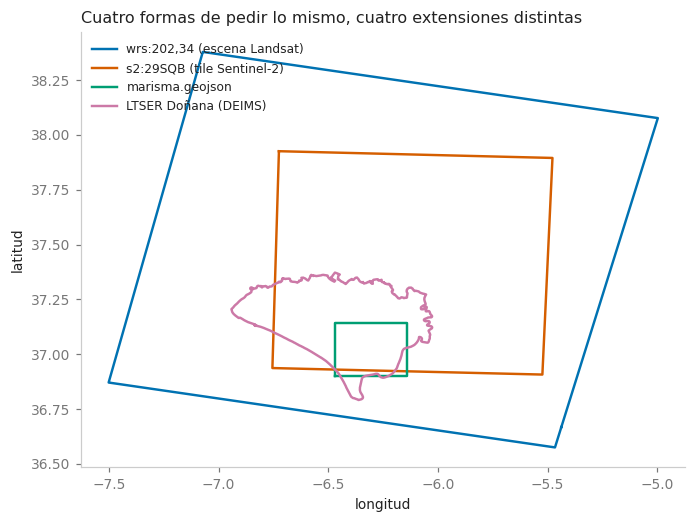

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
for (nombre, geom), hue in zip(rois.items(), HUES):
    for anillo in ee.Geometry(geom).coordinates().getInfo():
        trozos = anillo if isinstance(anillo[0][0], list) else [anillo]
        for trozo in trozos:
            xs, ys = zip(*trozo)
            ax.plot(xs, ys, lw=1.6, color=hue)
    ax.plot([], [], lw=1.6, color=hue, label=nombre)

ax.set_aspect('equal')
ax.set_xlabel('longitud'); ax.set_ylabel('latitud')
ax.set_title('Cuatro formas de pedir lo mismo, cuatro extensiones distintas',
             loc='left', fontsize=10.5)
ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

La escena de Landsat y el tile de Sentinel-2 son cómodos para una prueba rápida, pero son
**cuadrículas del satélite**, no el sitio de estudio: traen de todo, incluido mar. El
polígono de DEIMS es la plataforma LTSER de Doñana tal y como está publicada, y es el que
usaremos en la última sección.

### La quinta: dibujarlo a mano

Ejecuta la celda, dibuja un rectángulo o un polígono con la barra de herramientas del mapa,
y la celda siguiente lo recoge: `Map.user_roi` te devuelve la geometría y
`Map.draw_last_feature` el *feature* completo; las dos se le pueden pasar a `roi=`.
Si no dibujas nada, `user_roi` es `None` y seguimos con la marisma — así el notebook no
se rompe si lo ejecutas de un tirón.

In [5]:
Map = geemap.Map(center=[37.0, -6.35], zoom=9)
Map.add_basemap('SATELLITE')
Map

Map(center=[37.0, -6.35], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [6]:
roi = Map.user_roi if Map.user_roi is not None else rois['marisma.geojson']
print('ROI dibujado por ti' if Map.user_roi is not None else 'ROI por defecto: la marisma')
print('%.0f km²' % (ee.Geometry(roi).area(1000).getInfo() / 1e6))

ROI por defecto: la marisma


782 km²


## 2. El estadístico manda

El compuesto estacional clásico de Ndvi2Gif: un año, cuatro periodos, y el **máximo** de
NDVI dentro de cada uno. Las tres primeras estaciones van a rojo, verde y azul, y lo que
ves son las diferencias de fenología — no un color "bonito", sino *cuándo* verdea cada
cosa. En la marisma, el arrozal y el cultivo de regadío saltan a la vista frente al
matorral y el pinar.

In [7]:
MARISMA = rois['marisma.geojson']

estacional = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                             start_year=2024, end_year=2024, key='max',
                             cloud_filter=True, max_cloud_cover=20)
compuesto = estacional.get_year_composite().first()
print(compuesto.bandNames().getInfo())

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


['winter', 'spring', 'summer', 'autumn']


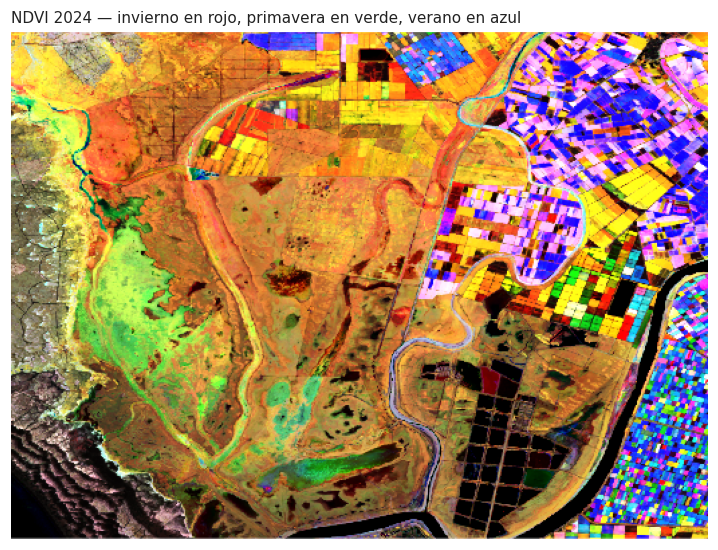

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 5.4))
ax.imshow(miniatura(compuesto, {'bands': ['winter', 'spring', 'summer'],
                                'min': 0.05, 'max': 0.85}, MARISMA))
ax.set_title('NDVI 2024 — invierno en rojo, primavera en verde, verano en azul',
             loc='left', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

Ahora lo que de verdad cambia el mapa. El mismo índice, el mismo verano, el mismo año: solo
cambia **el reductor** con el que se resume la pila de imágenes de esos tres meses.

- `key='max'` — lo más verde que llegó a estar. Es el que usa el GIF clásico, y el que más
  se contamina con un píxel raro: una nube mal enmascarada o un borde de nube deja un
  máximo altísimo.
- `key='median'` — el estado típico del verano. Es el honesto para comparar entre años.
- `key='percentile'` con `percentile=90` — casi el máximo, pero sin el píxel raro.
- `key='min'` — el suelo, el agua, lo peor del verano. Útil para ver lo que *no* verdea.

In [9]:
ESTADISTICOS = [('max', None, 'máximo'), ('median', None, 'mediana'),
                ('percentile', 90, 'percentil 90'), ('min', None, 'mínimo')]

veranos = {}
for key, pct, etiqueta in ESTADISTICOS:
    extra = {'percentile': pct} if pct is not None else {}
    verano = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                             start_year=2024, end_year=2024, key=key,
                             cloud_filter=True, max_cloud_cover=20,
                             **extra).get_year_composite().first().select('summer')
    veranos[etiqueta] = verano

medias = pd.Series({etiqueta: imagen.reduceRegion(
                        ee.Reducer.mean(), MARISMA, 100, maxPixels=1e9).get('summer')
                    for etiqueta, imagen in veranos.items()})
medias = pd.Series(ee.Dictionary(medias.to_dict()).getInfo())
medias.round(3).to_frame('NDVI medio del verano de 2024 en la marisma')

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


,NDVI medio del verano de 2024 en la marisma
mediana,0.226
máximo,0.298
mínimo,0.130
percentil 90,0.284


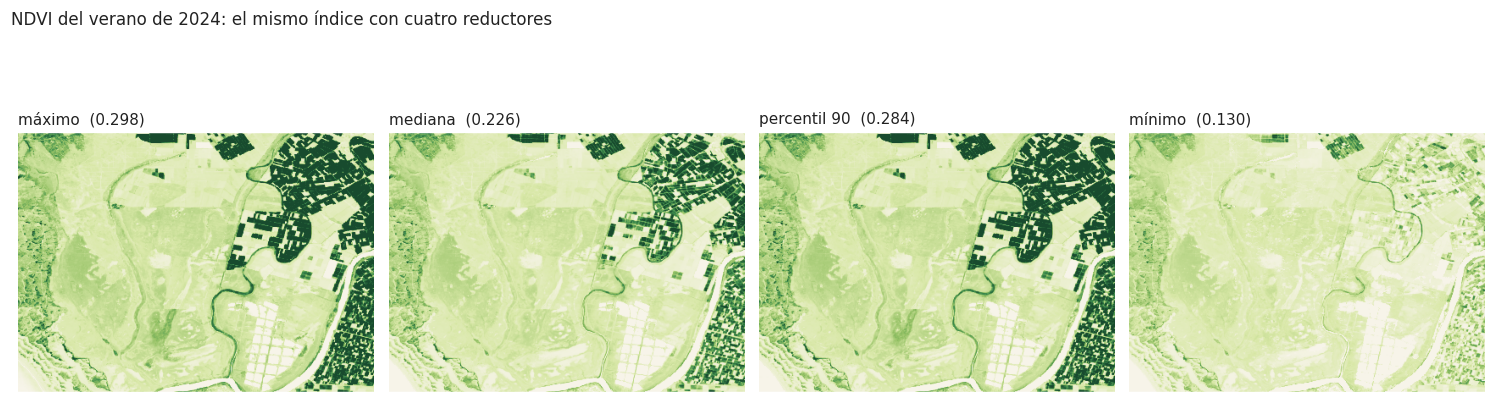

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(13.6, 4.2))
for ax, (etiqueta, imagen) in zip(axes, veranos.items()):
    ax.imshow(miniatura(imagen, {'min': 0.0, 'max': 0.8, 'palette': VERDE}, MARISMA,
                        dimensiones=420))
    ax.set_title('%s  (%.3f)' % (etiqueta, medias[etiqueta]), loc='left', fontsize=10)
    ax.axis('off')
fig.suptitle('NDVI del verano de 2024: el mismo índice con cuatro reductores',
             x=0.005, ha='left', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### El mismo ejercicio, pero en el mapa

Lo de arriba son figuras para un artículo. Para mirar de verdad, los compuestos se tiran al
mapa y se encienden y apagan: el bucle de abajo es el que sale en los ejemplos del
repositorio, con las tres primeras estaciones como RGB y un estadístico por capa.

In [11]:
VIZ = {'bands': ['winter', 'spring', 'summer'], 'min': 0.05, 'max': 0.85}

Map2 = geemap.Map()
Map2.centerObject(MARISMA, 11)
Map2.add_basemap('SATELLITE')
for key, pct in [('max', None), ('median', None), ('mean', None),
                 ('percentile', 90), ('percentile', 95)]:
    extra = {'percentile': pct} if pct is not None else {}
    compuesto_key = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                                    start_year=2024, end_year=2024, key=key,
                                    cloud_filter=True, max_cloud_cover=20,
                                    **extra).get_year_composite().first()
    etiqueta = key if pct is None else 'percentil %d' % pct
    Map2.addLayer(compuesto_key, VIZ, 'NDVI 2024 — %s' % etiqueta, shown=key == 'max')
Map2

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


...

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


Map(center=[37.01997489650197, -6.305000000000171], controls=(WidgetControl(options=['position', 'transparent_…

### Y el GIF, que es de donde viene el nombre

`get_gif()` monta la animación: un fotograma por año, con tres periodos como RGB. Ocho años
de la marisma en una línea de código. Deja dos ficheros en el directorio de trabajo, el GIF
y una versión con el año rotulado.

Para llevarse los compuestos a QGIS, el equivalente es `get_export()` (un GeoTIFF por
periodo) o `get_export_single()` para una imagen concreta.

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2017: 4/4 periods with data using ndvi index


Year 2018: 4/4 periods with data using ndvi index


Year 2019: 4/4 periods with data using ndvi index


Year 2020: 4/4 periods with data using ndvi index


...

Year 2022: 4/4 periods with data using ndvi index


Year 2023: 4/4 periods with data using ndvi index


Year 2024: 4/4 periods with data using ndvi index
Generating URL...


Please wait ...


The GIF image has been saved to: /tmp/claude-1000/-home-diego-git-Ndvi2Gif/058151fe-0128-43aa-8abd-f2684877e860/scratchpad/donana_ndvi.gif


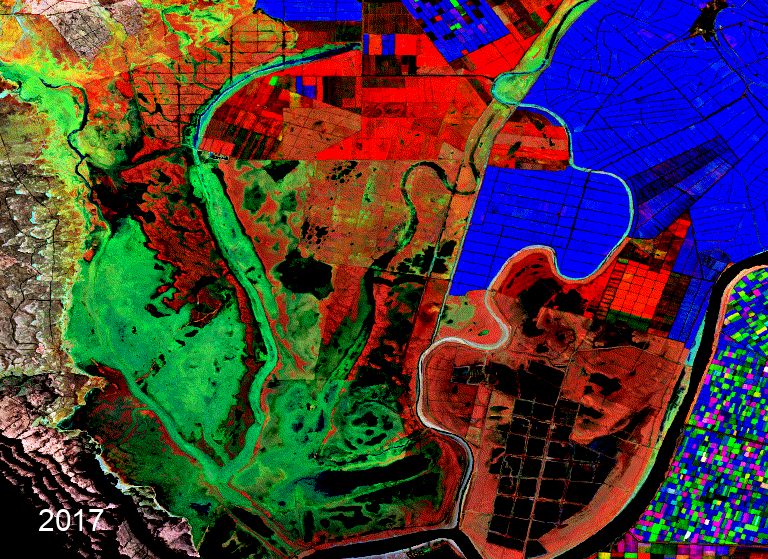

In [12]:
serie = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                        start_year=2017, end_year=2024, key='median',
                        cloud_filter=True, max_cloud_cover=20)
serie.get_gif('donana_ndvi.gif', bands=['winter', 'spring', 'summer'])

Animacion('donana_ndvi_texted.gif')

## 3. Cuatro décadas de inundación con MNDWI

Y ahora la que merece la pena enseñar. MNDWI (verde frente a SWIR) es positivo sobre agua
libre, así que:

- el **percentil 95 de MNDWI de un año** es, píxel a píxel, lo más inundado que estuvo ese
  año — sin que una sola imagen con nube decida el resultado, como haría el máximo;
- el **máximo de esos percentiles dentro de una década** es la mayor inundación que la
  década llegó a tener en cada punto.

Cuarenta años de Landsat sobre el LTSER de Doñana, cuatro décadas, dos líneas de código por
década. Esto es lo que la librería hace rápido.

In [13]:
LTSER = rois['LTSER Doñana (DEIMS)']
DECADAS = [(1985, 1994), (1995, 2004), (2005, 2014), (2015, 2024)]
ETIQUETAS = ['%d-%d' % (a, b) for a, b in DECADAS]


def p95_anual(anio):
    """El percentil 95 de MNDWI de un año: la inundación máxima robusta de ese año."""
    return NdviSeasonality(roi=LTSER, sat='Landsat', index='mndwi', periods=1,
                           start_year=anio, end_year=anio, key='percentile',
                           percentile=95, cloud_filter=True,
                           max_cloud_cover=60).get_year_composite().first()


anuales = {etiqueta: ee.ImageCollection([p95_anual(anio) for anio in range(a, b + 1)])
           for etiqueta, (a, b) in zip(ETIQUETAS, DECADAS)}

# dos maneras de resumir la década, y no dan lo mismo
maxima = {e: c.max().rename('mndwi') for e, c in anuales.items()}       # el año más húmedo
tipica = {e: c.median().rename('mndwi') for e, c in anuales.items()}    # el año corriente
print('grafos montados; Earth Engine todavía no ha calculado nada')

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1985: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1986: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1987: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1988: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


...

Year 2020: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2021: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using mndwi index
grafos montados; Earth Engine todavía no ha calculado nada


In [14]:
HECTAREAS = ee.Image.pixelArea().divide(1e4)
LTSER_HA = LTSER.area(1000).getInfo() / 1e4

SENSORES = ['LANDSAT/LT04/C02/T1_L2', 'LANDSAT/LT05/C02/T1_L2',
            'LANDSAT/LE07/C02/T1_L2', 'LANDSAT/LC08/C02/T1_L2',
            'LANDSAT/LC09/C02/T1_L2']
archivo = ee.ImageCollection(SENSORES[0])
for nombre in SENSORES[1:]:
    archivo = archivo.merge(ee.ImageCollection(nombre))
archivo = archivo.filterBounds(LTSER).filter(ee.Filter.lte('CLOUD_COVER', 60))


def hectareas_de_agua(imagen):
    return imagen.gt(0).selfMask().multiply(HECTAREAS).reduceRegion(
        ee.Reducer.sum(), LTSER, 100, maxPixels=1e10, bestEffort=True,
        tileScale=4).values().get(0)


peticion = ee.List([
    ee.Dictionary({'década': etiqueta,
                   'escenas': archivo.filterDate('%d-01-01' % a,
                                                 '%d-01-01' % (b + 1)).size(),
                   'ha (máximo de la década)': hectareas_de_agua(maxima[etiqueta]),
                   'ha (mediana de la década)': hectareas_de_agua(tipica[etiqueta])})
    for etiqueta, (a, b) in zip(ETIQUETAS, DECADAS)])

superficie = pd.DataFrame(peticion.getInfo()).set_index('década').loc[ETIQUETAS]
superficie['% máximo'] = 100 * superficie['ha (máximo de la década)'] / LTSER_HA
superficie['% mediana'] = 100 * superficie['ha (mediana de la década)'] / LTSER_HA
superficie.round(1)

,escenas,ha (mediana de la década),ha (máximo de la década),% máximo,% mediana
década,,,,,
1985-1994,417,67478.3,259661.4,95.1,24.7
1995-2004,594,70591.5,110432.7,40.4,25.8
2005-2014,646,65398.2,102283.7,37.4,23.9
2015-2024,1236,55977.9,81783.6,29.9,20.5


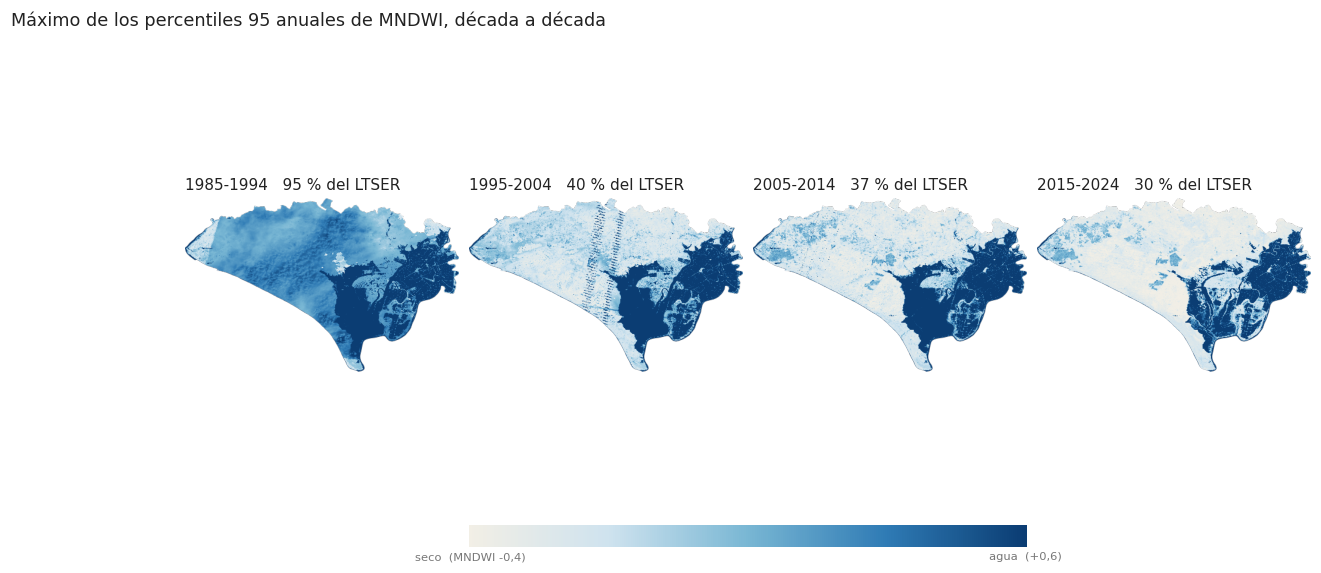

In [15]:
fig = plt.figure(figsize=(13.2, 5.6))
grid = fig.add_gridspec(2, 4, height_ratios=[14, 0.7], hspace=0.12, wspace=0.04)

for columna, etiqueta in enumerate(ETIQUETAS):
    ax = fig.add_subplot(grid[0, columna])
    ax.imshow(miniatura(maxima[etiqueta], {'min': -0.4, 'max': 0.6, 'palette': AGUA},
                        LTSER, dimensiones=460))
    ax.set_title('%s   %.0f %% del LTSER' % (etiqueta, superficie.loc[etiqueta, '% máximo']),
                 loc='left', fontsize=10)
    ax.axis('off')

barra(fig.add_subplot(grid[1, 1:3]), AGUA, ['seco  (MNDWI -0,4)', 'agua  (+0,6)'])
fig.suptitle('Máximo de los percentiles 95 anuales de MNDWI, década a década',
             x=0.005, ha='left', fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

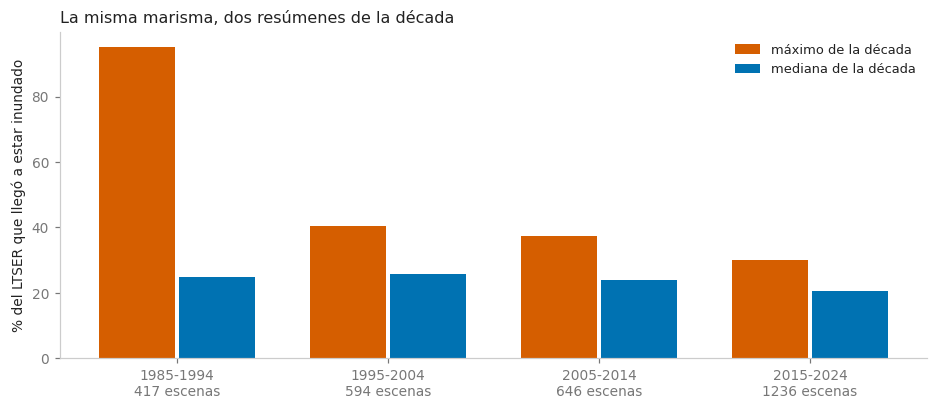

In [16]:
fig, ax = plt.subplots(figsize=(8.6, 3.8))
x = np.arange(len(ETIQUETAS))
ancho = 0.38
ax.bar(x - ancho / 2, superficie['% máximo'], ancho * 0.94, color=HUES[1],
       label='máximo de la década')
ax.bar(x + ancho / 2, superficie['% mediana'], ancho * 0.94, color=HUES[0],
       label='mediana de la década')
ax.set_xticks(x)
ax.set_xticklabels(['%s\n%d escenas' % (e, superficie.loc[e, 'escenas'])
                    for e in ETIQUETAS])
ax.set_ylabel('% del LTSER que llegó a estar inundado')
ax.set_title('La misma marisma, dos resúmenes de la década', loc='left', fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

### Lo que de verdad dice la tabla

Leída por la columna del máximo, Doñana se ha secado sin remedio: del **95 % del LTSER**
inundado en algún momento de 1985-94 al **30 %** en 2015-24. Es una conclusión redonda, es
la que todo el mundo espera, y es falsa.

Mira la columna de las escenas: **417** imágenes de Landsat en la primera década y
**1 236** en la última, tres veces más. Con 417 escenas en diez años, el percentil 95 de un
año es prácticamente su máximo, y el máximo de diez máximos acaba recogiendo cualquier
observación mala —bruma, sombra, un borde de nube— en cualquier punto del mapa, incluidas
las dunas y el pinar, que no se inundan jamás. Ese 95 % no es marisma: es ruido acumulado
durante diez años.

La **mediana** de los p95 anuales —el año corriente de la década en lugar del extremo—
apenas se mueve: **24,7 / 25,8 / 23,9 / 20,5 %** del LTSER. Y ahí sí queda una señal, la de
la última década: en torno a un 15 % menos de superficie inundada típica que en las tres
anteriores. Además es una señal conservadora, porque el sesgo del muestreo empuja al alza y
la última década es justo la que más veces se miró: si con tres veces más imágenes sale
menos agua, es que hay menos agua.

La regla, que sirve para todo lo que hagas con series largas de satélite: **un estadístico
de extremo crece con el número de observaciones, y uno central mucho menos**. Si vas a
comparar décadas, usa el central — o pon el número de escenas al lado de la cifra.

Es exactamente el mismo problema que el tutorial de incendios del libro trata a fondo, con
cuarenta años de Landsat sobre toda la península. Y para el hidroperiodo de verdad —cuántos
días estuvo inundado cada píxel, no solo si lo estuvo— la librería tiene una clase entera,
`HydroperiodAnalyzer`, que es el siguiente notebook del taller.

## Para seguir

- El libro: **https://digdgeo.github.io/Ndvi2Gif/** — tutoriales, referencia de los más de
  40 índices y las opciones de ROI con todo detalle.
- `02_hidroperiodo.ipynb` y `03_fenologia.ipynb` en esta misma carpeta.
- Y si algo no funciona: https://github.com/Digdgeo/Ndvi2Gif/issues